# 00 - Diagnóstico Pseudo-RGB sobre GeoRSCLIP

**Proyecto:** GeoVisionCLIP-Cali
**Asignado por:** Ferro (Clase 35.1, lunes 2026-05-11, S15)
**Ejecutores propuestos:** Isabella y Natalia
**Origen consolidado:** `agent-docs/handoffs/13-05-2026/13-05-2026-consolidado-fixes-rediseno-pipeline.md` punto 2

---

## Objetivo

Descartar que el problema del SAE colapsado sea **upstream** en el image encoder GeoRSCLIP. Si el encoder ya devuelve embeddings con `cos_sim_media > 0.85` antes de tocar el SAE, ningún rediseño del SAE puede recuperar discriminabilidad.

## Procedimiento (orden de Ferro)

1. Cargar 50 escenas aleatorias del Zarr actual `(363, 4, 224, 224)`.
2. Para cada canal del Sentinel-2 (`Blue=B02`, `Green=B03`, `Red=B04`, `NIR=B08`), construir un **pseudo-RGB** replicando el canal 3 veces a `(3, 224, 224)`.
3. Normalizar con `CLIP_MEAN/STD` oficiales.
4. Pasar el batch por `GeoRSCLIP.encode_image()` **congelado, sin SAE**.
5. Calcular matriz de cosine similarity `(50, 50)` y reportar `cos_sim_media` (excluyendo diagonal), `cos_sim_min`, `cos_sim_max`.

## Tabla de criterios de decisión

| Resultado pseudo-RGB | Interpretación | Acción sobre el pipeline |
|---|---|---|
| `cos_sim_media < 0.7` en cualquier canal | El image encoder discrimina escenas; problema está sólo en el SAE | Aplicar D (Late Fusion) directo, **omitir A** |
| `cos_sim_media > 0.85` en todos los canales | El image encoder está colapsado sobre este dataset (OOD severo) | Aplicar **A (tiling subscene) ANTES de D**, o aceptar fine-tuning del encoder con Ferro |
| `cos_sim_media` entre 0.7 y 0.85 | Discriminación parcial | Aplicar D solo; evaluar A si tras D el `cos_sim_media` reconstruido sigue > 0.9 |

**Nota sobre el orden de canales del Zarr**: el ETL del notebook 01 escribe los canales en orden `['B02', 'B03', 'B04', 'B08']`, así que:
- Índice 0 = Blue (B02)
- Índice 1 = Green (B03)
- Índice 2 = Red (B04)
- Índice 3 = NIR (B08)


## 1 - Optimización GPU

In [1]:
import torch

torch.cuda.set_per_process_memory_fraction(0.9)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo activo: {device}')
if device.type == 'cuda':
    print(f'  GPU    : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')


Dispositivo activo: cuda
  GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM   : 6.44 GB


## 2 - Dependencias e Imports

In [2]:
import warnings
from pathlib import Path

import numpy as np
import zarr
import torch
import torch.nn.functional as F

import open_clip
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')


PyTorch : 2.4.1+cu118
CUDA    : 11.8


## 3 - Configuración global

In [3]:
ZARR_PATH      = Path(r'D:\\analitica\\procesado_zarr\\sentinel2_224.zarr')
GEORSCLIP_DIR  = Path(r'C:\\Users\\isape\\OneDrive\\Escritorio\\ANALITICA\\Proyecto3\\GeoRSCLIP')
GEORSCLIP_CKPT = GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt'

OUTPUT_DIR = Path(r'D:\\analitica\\outputs_geovision\\diag_pseudoRGB')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Lineamiento del proyecto: SEED en {67, 137, 777}, no 42
SEED = 67
torch.manual_seed(SEED)
np.random.seed(SEED)

# Muestreo
N_ESCENAS    = 50
ZARR_KEY     = 'arr'  # ajustar si el zarr usa otro nombre de array
BAND_NAMES   = ['Blue (B02)', 'Green (B03)', 'Red (B04)', 'NIR (B08)']
BAND_INDICES = [0, 1, 2, 3]

# Normalizacion CLIP oficial (Open-CLIP defaults)
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)

print(f'SEED         : {SEED}')
print(f'N_ESCENAS    : {N_ESCENAS}')
print(f'ZARR_PATH    : {ZARR_PATH}')
print(f'  existe     : {ZARR_PATH.exists()}')
print(f'GeoRSCLIP    : {GEORSCLIP_CKPT}')
print(f'  existe     : {GEORSCLIP_CKPT.exists()}')


SEED         : 67
N_ESCENAS    : 50
ZARR_PATH    : D:\analitica\procesado_zarr\sentinel2_224.zarr
  existe     : True
GeoRSCLIP    : C:\Users\isape\OneDrive\Escritorio\ANALITICA\Proyecto3\GeoRSCLIP\ckpt\RS5M_ViT-B-32.pt
  existe     : True


## 4 - Carga del Zarr y muestreo de 50 escenas

In [4]:
root = zarr.open(str(ZARR_PATH), mode='r')

# Localizar el array. v2 consolidated suele tener un solo array de imagenes.
print('Estructura Zarr:')
def _ls(node, prefix=''):
    if hasattr(node, 'items'):
        for k, v in node.items():
            print(f'  {prefix}{k}: shape={getattr(v, "shape", None)} dtype={getattr(v, "dtype", None)}')
            _ls(v, prefix + '  ')

_ls(root)

# Heuristica: tomar el primer array 4D del store
def _find_4d_array(node):
    if hasattr(node, 'items'):
        for _, v in node.items():
            res = _find_4d_array(v)
            if res is not None:
                return res
    elif hasattr(node, 'shape') and len(node.shape) == 4:
        return node
    return None

arr = _find_4d_array(root)
assert arr is not None, 'No se encontro un array 4D en el Zarr'
print(f'\nArray detectado: shape={arr.shape} dtype={arr.dtype}')

N_total = arr.shape[0]
rng = np.random.default_rng(SEED)
idx = rng.choice(N_total, size=min(N_ESCENAS, N_total), replace=False)
idx.sort()
print(f'Indices muestreados ({len(idx)}): {idx[:10]} ...')

# Cargar batch a memoria una sola vez (escenas pequenas: 4 canales x 224x224 = cerca de 200 KB c/u)
batch = np.stack([arr[i] for i in idx], axis=0)  # (N, 4, 224, 224)
print(f'Batch cargado: {batch.shape} dtype={batch.dtype}')
print(f'  min={batch.min():.4f} max={batch.max():.4f} mean={batch.mean():.4f}')


Estructura Zarr:
  bbox: shape=(363, 4) dtype=float64
  escena_id: shape=(363,) dtype=<U64
  fecha: shape=(363,) dtype=<U20
  images: shape=(363, 4, 224, 224) dtype=float32

Array detectado: shape=(363, 4, 224, 224) dtype=float32
Indices muestreados (50): [  4  29  34  40  55  62  74  79  95 100] ...
Batch cargado: (50, 4, 224, 224) dtype=float32
  min=-2.0000 max=4.6667 mean=-0.8957


## 5 - Carga del foundation model GeoRSCLIP congelado

Mismo procedimiento que el `03_Entrenamiento_SAE_Multimodal_v6.ipynb`: ViT-B/32 OpenAI base + inyección de pesos RS5M congelados.

In [5]:
print('Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...')

clip_model, _, _ = open_clip.create_model_and_transforms(
    'ViT-B/32', pretrained='openai'
)

possible = [GEORSCLIP_DIR / 'ckpt' / 'RS5M_ViT-B-32.pt',
            GEORSCLIP_DIR / 'RS5M_ViT-B-32.pt']
ckpt_found = next((p for p in possible if p.exists()), None)
assert ckpt_found is not None, f'Checkpoint no encontrado en {possible}'

checkpoint = torch.load(str(ckpt_found), map_location='cpu')
msg = clip_model.load_state_dict(checkpoint, strict=False)
print(f'  Missing: {len(msg.missing_keys)} | Unexpected: {len(msg.unexpected_keys)}')

clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad = False
clip_model = clip_model.to(device)

with torch.no_grad():
    dummy = torch.zeros(1, 3, 224, 224, device=device)
    EMBED_DIM = clip_model.encode_image(dummy).shape[-1]
print(f'EMBED_DIM    : {EMBED_DIM}')
print('GeoRSCLIP congelado y listo.')


Construyendo ViT-B/32 + inyectando pesos GeoRSCLIP...


  Missing: 0 | Unexpected: 0
EMBED_DIM    : 512
GeoRSCLIP congelado y listo.


## 6 - Función de pseudo-RGB y cálculo de cosine similarity

El procedimiento por canal:
1. Tomar el canal seleccionado del batch `(N, 224, 224)`.
2. Normalizar a `[0, 1]` por escena (min-max sobre el rango observado del canal).
3. Replicar 3 veces a `(N, 3, 224, 224)`.
4. Aplicar `CLIP_MEAN/STD`.
5. Pasar por `clip_model.encode_image()`.
6. Normalizar L2 y calcular matriz `(N, N)` de cosine similarity.

In [6]:
clip_mean = torch.tensor(CLIP_MEAN, device=device).view(1, 3, 1, 1)
clip_std  = torch.tensor(CLIP_STD,  device=device).view(1, 3, 1, 1)

@torch.no_grad()
def cos_sim_canal(batch_np: np.ndarray, canal_idx: int) -> dict:
    """Calcula matriz cos_sim para pseudo-RGB de un canal.

    Returns dict con la matriz y estadisticas (media excluyendo diagonal, min, max).
    """
    canal = batch_np[:, canal_idx, :, :].astype(np.float32)  # (N, 224, 224)

    # Normalizar a [0, 1] por escena
    mn = canal.reshape(canal.shape[0], -1).min(axis=1)[:, None, None]
    mx = canal.reshape(canal.shape[0], -1).max(axis=1)[:, None, None]
    canal_norm = (canal - mn) / np.where(mx - mn > 1e-8, mx - mn, 1.0)

    # Pseudo-RGB: replicar a (N, 3, 224, 224)
    rgb = np.stack([canal_norm, canal_norm, canal_norm], axis=1)
    t   = torch.from_numpy(rgb).to(device)
    t   = (t - clip_mean) / clip_std

    embs = clip_model.encode_image(t)
    embs = embs / embs.norm(dim=-1, keepdim=True)

    sim  = embs @ embs.T  # (N, N)
    sim_np = sim.cpu().numpy()

    # Media excluyendo diagonal
    N = sim_np.shape[0]
    mask = ~np.eye(N, dtype=bool)
    media = sim_np[mask].mean()
    # min/max excluyendo diagonal
    sin_diag = sim_np[mask]
    return {
        'matriz': sim_np,
        'cos_sim_media': float(media),
        'cos_sim_min':   float(sin_diag.min()),
        'cos_sim_max':   float(sin_diag.max()),
        'cos_sim_std':   float(sin_diag.std()),
    }


## 7 - Ejecución sobre los 4 canales

In [7]:
resultados = {}
for canal_idx, nombre in zip(BAND_INDICES, BAND_NAMES):
    print(f'\nProcesando canal {canal_idx} ({nombre})...')
    res = cos_sim_canal(batch, canal_idx)
    resultados[nombre] = res
    print(f'  cos_sim_media = {res["cos_sim_media"]:.4f}')
    print(f'  cos_sim_min   = {res["cos_sim_min"]:.4f}')
    print(f'  cos_sim_max   = {res["cos_sim_max"]:.4f}')
    print(f'  cos_sim_std   = {res["cos_sim_std"]:.4f}')



Procesando canal 0 (Blue (B02))...
  cos_sim_media = 0.9594
  cos_sim_min   = 0.8833
  cos_sim_max   = 0.9996
  cos_sim_std   = 0.0178

Procesando canal 1 (Green (B03))...
  cos_sim_media = 0.9591
  cos_sim_min   = 0.8886
  cos_sim_max   = 0.9993
  cos_sim_std   = 0.0174

Procesando canal 2 (Red (B04))...
  cos_sim_media = 0.9582
  cos_sim_min   = 0.8779
  cos_sim_max   = 0.9995
  cos_sim_std   = 0.0188

Procesando canal 3 (NIR (B08))...
  cos_sim_media = 0.9505
  cos_sim_min   = 0.8780
  cos_sim_max   = 0.9996
  cos_sim_std   = 0.0195


## 8 - Visualización: heatmap de matriz cos_sim por canal

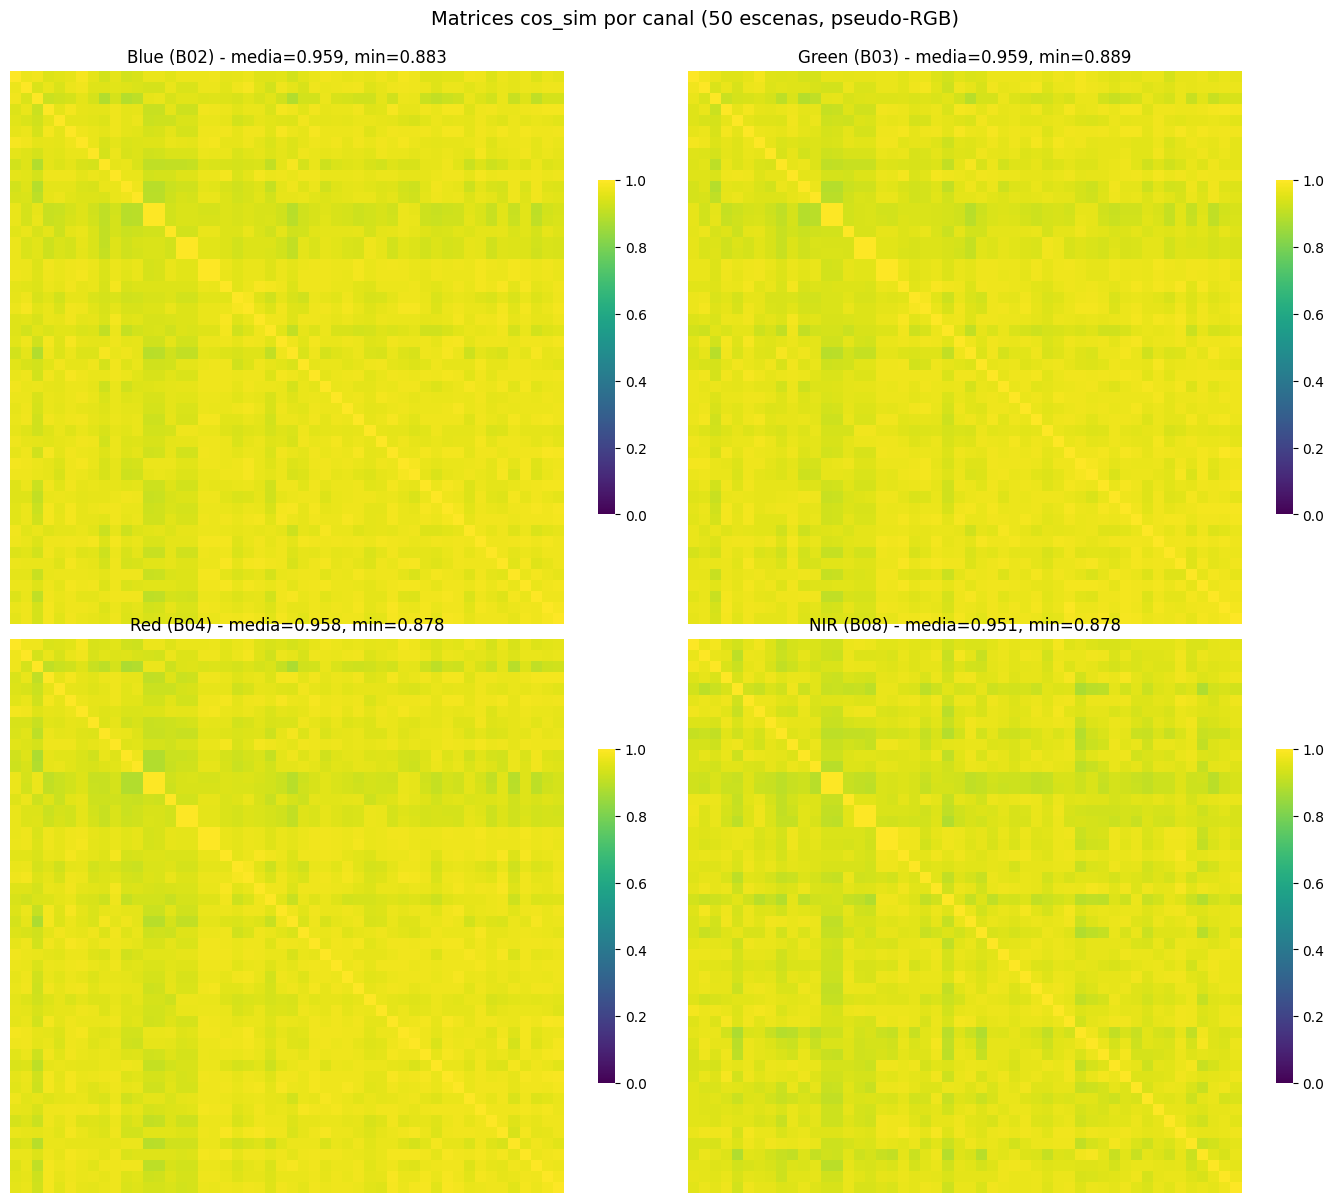

Heatmap guardado: D:\analitica\outputs_geovision\diag_pseudoRGB\cos_sim_heatmaps_por_canal.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (nombre, res) in zip(axes.flatten(), resultados.items()):
    sns.heatmap(res['matriz'], ax=ax, cmap='viridis', vmin=0.0, vmax=1.0,
                square=True, cbar_kws={'shrink': 0.6})
    ax.set_title(f'{nombre} - media={res["cos_sim_media"]:.3f}, min={res["cos_sim_min"]:.3f}')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Matrices cos_sim por canal (50 escenas, pseudo-RGB)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cos_sim_heatmaps_por_canal.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Heatmap guardado: {OUTPUT_DIR / "cos_sim_heatmaps_por_canal.png"}')


## 9 - Tabla de criterios y veredicto automatizado

In [9]:
import json

medias = {k: v['cos_sim_media'] for k, v in resultados.items()}
print('Resumen por canal:')
for k, v in medias.items():
    print(f'  {k:18s} -> cos_sim_media = {v:.4f}')

min_media = min(medias.values())
max_media = max(medias.values())

if min_media < 0.7:
    veredicto = 'A_INNECESARIO'
    accion    = 'El image encoder discrimina escenas en al menos un canal. Aplicar D (Late Fusion) directo, omitir A.'
elif max_media > 0.85:
    veredicto = 'A_OBLIGATORIO'
    accion    = 'El image encoder esta colapsado sobre este dataset (OOD severo). Aplicar A (tiling subscene) ANTES de D, o aceptar fine-tuning del encoder con autorizacion Ferro.'
else:
    veredicto = 'A_EVALUAR_POST_D'
    accion    = 'Discriminacion parcial. Aplicar D solo; si tras D el cos_sim_media reconstruido sigue > 0.9, escalar a A.'

print(f'\nVeredicto: {veredicto}')
print(f'Accion   : {accion}')

resumen = {
    'seed': SEED,
    'n_escenas': N_ESCENAS,
    'medias_por_canal': medias,
    'min_media': min_media,
    'max_media': max_media,
    'veredicto': veredicto,
    'accion': accion,
}
out_json = OUTPUT_DIR / 'veredicto_pseudoRGB.json'
out_json.write_text(json.dumps(resumen, indent=2), encoding='utf-8')
print(f'\nVeredicto guardado: {out_json}')


Resumen por canal:
  Blue (B02)         -> cos_sim_media = 0.9594
  Green (B03)        -> cos_sim_media = 0.9591
  Red (B04)          -> cos_sim_media = 0.9582
  NIR (B08)          -> cos_sim_media = 0.9505

Veredicto: A_OBLIGATORIO
Accion   : El image encoder esta colapsado sobre este dataset (OOD severo). Aplicar A (tiling subscene) ANTES de D, o aceptar fine-tuning del encoder con autorizacion Ferro.

Veredicto guardado: D:\analitica\outputs_geovision\diag_pseudoRGB\veredicto_pseudoRGB.json


## 10 - Próximos pasos

Reportar al equipo el archivo `D:\analitica\outputs_geovision\diag_pseudoRGB\veredicto_pseudoRGB.json` con:
- `medias_por_canal`
- `veredicto` (uno de `A_INNECESARIO`, `A_EVALUAR_POST_D`, `A_OBLIGATORIO`)
- `accion` resultante

Si el veredicto es `A_OBLIGATORIO`, abrir issue en el board para programar el rediseño A (tiling subscene torchgeo) antes de iniciar Camino D.

Si es `A_INNECESARIO` o `A_EVALUAR_POST_D`, proceder directamente al notebook `03_SAE_LateFusion_v7.ipynb`.